# 04 — Machine Learning Analysis

## Australian Energy Market Analytics

The earlier notebooks established clear temporal patterns in electricity demand and Regional Reference Price (RRP), together with a positive demand–price relationship and distinct behaviour during positive price spikes and negative-price periods.

This notebook extends the project from **descriptive and statistical analysis** into **predictive modelling**.

### Machine-learning objectives

1. **Regression:** predict continuous electricity spot prices (`RRP`) from demand and temporal features.
2. **Classification:** predict whether a five-minute interval is likely to experience an unusually high price spike.
3. Compare simple and nonlinear models using appropriate evaluation metrics.
4. Examine feature importance to identify which available variables contribute most to prediction.

> **Important:** The models are exploratory. They use only demand and time-based variables and therefore do not represent a production electricity-price forecasting system. Generator availability, renewable output, network constraints, interconnector flows, weather and bidding behaviour are not included in the dataset.

## 1. Setup and Data Loading

The cleaned dataset from the previous stages is loaded and ordered chronologically. Keeping the observations in time order is important because the model should be evaluated on later observations that were not used during training.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42

In [49]:
# Load the csv 
df = pd.read_csv(
    "../data/processed/clean_price_demand.csv",
    parse_dates=["SETTLEMENTDATE"]
)

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2026-08-01 00:05:00,8898.91,89.88,TRADE
1,NSW1,2026-08-01 00:10:00,9032.33,95.05,TRADE
2,NSW1,2026-08-01 00:15:00,8989.12,88.88,TRADE
3,NSW1,2026-08-01 00:20:00,9036.72,88.88,TRADE
4,NSW1,2026-08-01 00:25:00,8946.67,84.79,TRADE


In [50]:
print(f"Observations: {len(df):,}")
print(f"Date range: {df['SETTLEMENTDATE'].min()} to {df['SETTLEMENTDATE'].max()}")
print("Missing values: ")
print(df[["SETTLEMENTDATE", "TOTALDEMAND", "RRP"]].isna().sum())

Observations: 7,776
Date range: 2026-08-01 00:05:00 to 2026-08-28 00:00:00
Missing values: 
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
dtype: int64


## 2. Feature Engineering

The existing analysis showed that both **demand** and **time of day** are associated with spot-price behaviour. These variables are therefore used as the initial predictors.

Hour and day-of-week are cyclical variables: 23:00 is close to 00:00, and Sunday is close to Monday. Sine and cosine transformations preserve this cyclical structure more naturally than treating these variables as ordinary integers.

In [51]:
df["hour"] = df["SETTLEMENTDATE"].dt.hour
df["day_of_week"] = df["SETTLEMENTDATE"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour of day
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclical encoding for day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

features = [
    "TOTALDEMAND",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]

df[features].head()

,TOTALDEMAND,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
0,8898.91,0.0,1.0,-0.974928,-0.222521,1
1,9032.33,0.0,1.0,-0.974928,-0.222521,1
2,8989.12,0.0,1.0,-0.974928,-0.222521,1
3,9036.72,0.0,1.0,-0.974928,-0.222521,1
4,8946.67,0.0,1.0,-0.974928,-0.222521,1


### Why these features?

- `TOTALDEMAND` captures the system-demand conditions that were strongly associated with RRP in the previous notebook.
- `hour_sin` and `hour_cos` capture recurring intraday patterns without creating an artificial gap between 23:00 and 00:00.
- `dow_sin`, `dow_cos`, and `is_weekend` represent weekly and weekday/weekend structure.

These features intentionally remain simple so that model performance can be interpreted as the predictive value of **demand and timing alone**.

## 3. Chronological Train-Test Split

A random train–test split is avoided because neighbouring five-minute electricity-market observations are strongly related through time. Randomly mixing early and late observations could produce an unrealistically easy evaluation.

The first **80%** of observations are used for training and the final **20%** are reserved for testing.

In [52]:
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print(f"Training observations: {len(train):,}")
print(f"Testing observations:  {len(test):,}")
print(f"Training period: {train['SETTLEMENTDATE'].min()} to {train['SETTLEMENTDATE'].max()}")
print(f"Testing period:  {test['SETTLEMENTDATE'].min()} to {test['SETTLEMENTDATE'].max()}")

Training observations: 6,220
Testing observations:  1,556
Training period: 2026-08-01 00:05:00 to 2026-08-22 14:20:00
Testing period:  2026-08-22 14:25:00 to 2026-08-28 00:00:00


# Part A — Spot Price Regression

## 4. Regression Objective

The first machine-learning task predicts the continuous Regional Reference Price (`RRP`). Three models are compared with a naive baseline:

- Mean-price baseline
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Performance is evaluated using **MAE**, **RMSE**, and **R²**.

- **MAE** measures the average absolute prediction error.
- **RMSE** penalises large errors more strongly and is useful when price spikes are important.
- **R²** measures how much variation in the test-set RRP is explained by the model relative to predicting the test mean.

In [53]:
X_train = train[features]
X_test = test[features]
y_train = train["RRP"]
y_test = test["RRP"]

### 4.1 Naive Baseline

Before evaluating machine-learning models, a baseline is created that predicts the **training-set mean RRP** for every test observation. A useful predictive model should outperform this benchmark.

In [54]:
baseline_pred = np.full(len(y_test), y_train.mean())

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

baseline_metrics = regression_metrics(y_test, baseline_pred)
baseline_metrics

{'MAE': 36.146708265484094,
 'RMSE': np.float64(45.85728941553226),
 'R²': -0.06972348132597439}

### 4.2 Linear Regression

Linear Regression provides an interpretable benchmark and extends the earlier one-variable demand–price regression by including temporal features.

In [43]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_metrics = regression_metrics(y_test, linear_pred)
linear_metrics

{'MAE': 30.597857202742187,
 'RMSE': np.float64(39.03360644660604),
 'R²': 0.22494570654787194}

### 4.3 Decision Tree Regressor

A Decision Tree can capture nonlinear relationships and interactions that Linear Regression may miss. Tree depth is restricted to reduce overfitting.

In [55]:
tree_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_metrics = regression_metrics(y_test, tree_pred)
tree_metrics

{'MAE': 28.66149332599514,
 'RMSE': np.float64(38.93549533670145),
 'R²': 0.2288370134840333}

### 4.4 Random Forest Regressor

Random Forest averages many decision trees, allowing it to model nonlinear relationships while generally being more stable than a single tree.

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = regression_metrics(y_test, rf_pred)
rf_metrics

{'MAE': 31.760648626866733,
 'RMSE': np.float64(41.51591422409945),
 'R²': 0.1232334342724225}

In [57]:
regression_results = pd.DataFrame([
    {"Model": "Mean Baseline", **baseline_metrics},
    {"Model": "Linear Regression", **linear_metrics},
    {"Model": "Decision Tree", **tree_metrics},
    {"Model": "Random Forest", **rf_metrics}
]).set_index("Model")

regression_results.round(3)

,MAE,RMSE,R²
Model,,,
Mean Baseline,36.147,45.857,-0.070
Linear Regression,30.598,39.034,0.225
Decision Tree,28.661,38.935,0.229
Random Forest,31.761,41.516,0.123


### Model 1 : Linear regression

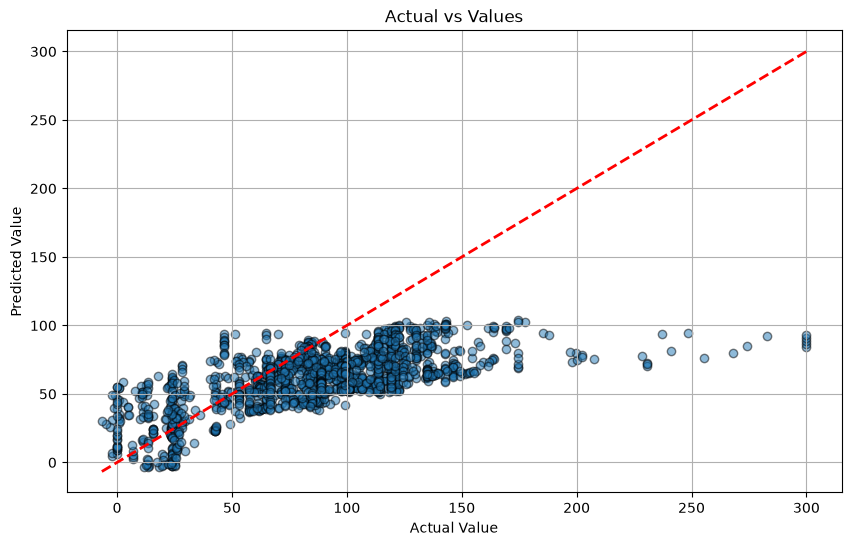

In [14]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, linear_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Values")
plt.grid()
plt.show()

In [15]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.3f}")

Linear Regression MAE: 32.39
Linear Regression RMSE: 41.96
Linear Regression R²: 0.104


#### Linear Regression

Linear Regression is used as the first predictive model because it provides a
simple and interpretable baseline for the relationship between demand,
time-related features and electricity spot prices.

Its performance is evaluated using:

- **MAE** — average absolute prediction error;
- **RMSE** — gives greater weight to large prediction errors; and
- **R²** — proportion of variation in RRP accounted for by the model.

### Model 2 : Decision Tree Regressor

In [16]:
tree_model = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

In [17]:
tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_pred
    )
)

tree_r2 = r2_score(
    y_test,
    tree_pred
)

print(f"Decision Tree MAE: {tree_mae:.2f}")
print(f"Decision Tree RMSE: {tree_rmse:.2f}")
print(f"Decision Tree R²: {tree_r2:.3f}")

Decision Tree MAE: 29.83
Decision Tree RMSE: 40.08
Decision Tree R²: 0.183


### Model 3: Random Forest Regressor

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [19]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²: {rf_r2:.3f}")

Random Forest MAE: 31.46
Random Forest RMSE: 41.46
Random Forest R²: 0.126


### Compare models

In [20]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

model_results.round(3)

,Model,MAE,RMSE,R²
0,Baseline,36.147,45.857,-0.070
1,Linear Regression,32.394,41.958,0.104
2,Decision Tree,29.827,40.079,0.183
3,Random Forest,31.462,41.456,0.126


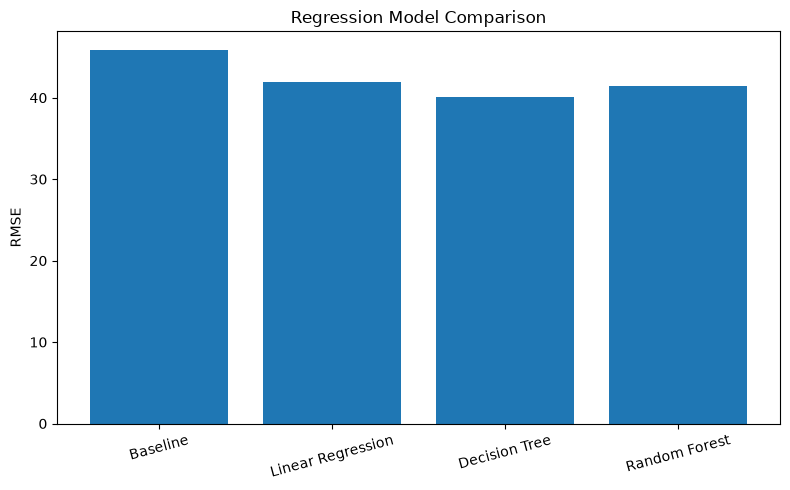

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Regression Model Comparison")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

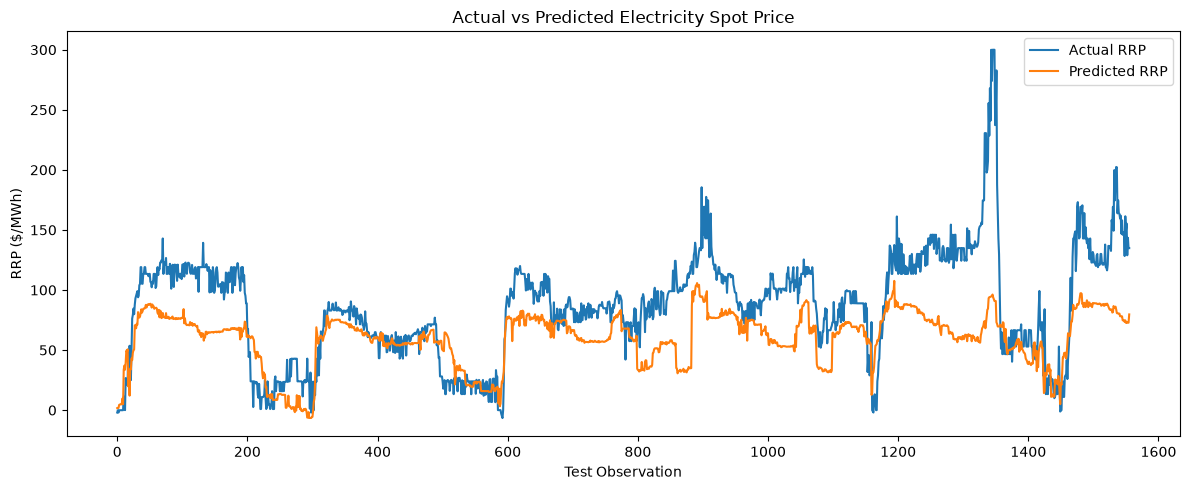

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.reset_index(drop=True),
    label="Actual RRP"
)

plt.plot(
    rf_pred,
    label="Predicted RRP"
)

plt.xlabel("Test Observation")
plt.ylabel("RRP ($/MWh)")
plt.title("Actual vs Predicted Electricity Spot Price")

plt.legend()
plt.tight_layout()
plt.show()

# 3. Price-Spike Classification

The second machine-learning task focuses on predicting whether an electricity
market interval is likely to experience an unusually high price.

A price spike is defined using the same 95th-percentile threshold developed in
the previous analysis. This converts the problem into binary classification:

- **0 = Normal price**
- **1 = Price spike**

Because price spikes represent only a small proportion of observations, model
performance is evaluated using precision, recall, F1-score and ROC-AUC rather
than accuracy alone.

In [23]:
spike_threshold = df["RRP"].quantile(0.95)

df["price_spike"] = (
    df["RRP"] > spike_threshold
).astype(int)

In [24]:
X_cls = df[
    [
        "TOTALDEMAND",
        "hour",
        "day_of_week",
        "is_weekend"
    ]
]

y_cls = df["price_spike"]

In [25]:
X_train_cls = X_cls.iloc[:split_index]
X_test_cls = X_cls.iloc[split_index:]

y_train_cls = y_cls.iloc[:split_index]
y_test_cls = y_cls.iloc[split_index:]

### Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(
    X_train_cls,
    y_train_cls
)

log_pred = log_model.predict(X_test_cls)
log_prob = log_model.predict_proba(X_test_cls)[:, 1]

In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test_cls,
        log_pred
    )
)

print(
    confusion_matrix(
        y_test_cls,
        log_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_cls,
        log_prob
    )
)

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1425
           1       0.37      0.24      0.29       131

    accuracy                           0.90      1556
   macro avg       0.65      0.60      0.62      1556
weighted avg       0.89      0.90      0.89      1556

[[1370   55]
 [  99   32]]
ROC-AUC: 0.8579402705236374


### Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

tree_cls = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_cls.fit(
    X_train_cls,
    y_train_cls
)

tree_cls_pred = tree_cls.predict(X_test_cls)
tree_cls_prob = tree_cls.predict_proba(X_test_cls)[:, 1]

### Random Forrest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_cls.fit(
    X_train_cls,
    y_train_cls
)

rf_cls_pred = rf_cls.predict(X_test_cls)
rf_cls_prob = rf_cls.predict_proba(X_test_cls)[:, 1]

### Comparison

In [30]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test_cls, log_pred),
        precision_score(y_test_cls, tree_cls_pred),
        precision_score(y_test_cls, rf_cls_pred)
    ],
    "Recall": [
        recall_score(y_test_cls, log_pred),
        recall_score(y_test_cls, tree_cls_pred),
        recall_score(y_test_cls, rf_cls_pred)
    ],
    "F1": [
        f1_score(y_test_cls, log_pred),
        f1_score(y_test_cls, tree_cls_pred),
        f1_score(y_test_cls, rf_cls_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test_cls, log_prob),
        roc_auc_score(y_test_cls, tree_cls_prob),
        roc_auc_score(y_test_cls, rf_cls_prob)
    ]
})

classification_results.round(3)

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.368,0.244,0.294,0.858
1,Decision Tree,0.352,0.282,0.314,0.704
2,Random Forest,0.333,0.115,0.170,0.827


In [31]:
feature_importance = pd.Series(
    rf_cls.feature_importances_,
    index=X_train_cls.columns
).sort_values(ascending=False)

feature_importance

TOTALDEMAND    0.535338
day_of_week    0.219855
hour           0.178978
is_weekend     0.065828
dtype: float64

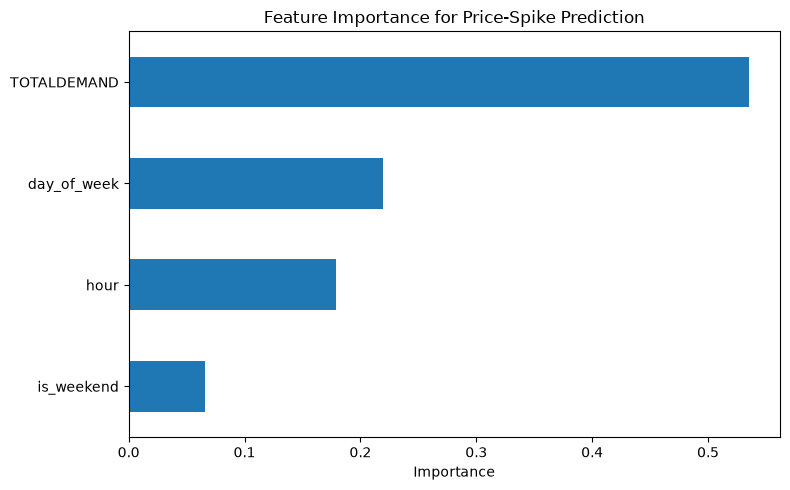

In [32]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("Feature Importance for Price-Spike Prediction")

plt.tight_layout()
plt.show()